## K-means Clustering Results (K = 3) (user_fingerprint_B_lex_clusters_scaled.csv)

### Why K = 3?
- We tested different values of K using **Elbow Method** and **Silhouette Score**.
- Although **K = 2** had the highest silhouette score, it was too coarse for product-level learner segmentation.
- **K = 4** created extremely small clusters (e.g., only a few users), which likely represent outliers.
- Therefore, we chose **K = 3** to balance **cluster quality** and **interpretability**.

---

### Cluster Sizes
| Cluster | Users | Note |
|---|---:|---|
| 0 | 2262 | Majority group |
| 1 | 413 | Stronger / more engaged group |
| 2 | 34 | Very advanced / extreme group |

---

### Cluster Interpretation (Standardized Means)
> Positive values mean **above average**, negative values mean **below average**.

**Key features**
- `max_history_seen`: learning exposure / how much content the learner has seen  
- `vocab_size`: estimated vocabulary size  
- `learning_speed`: learning pace  
- `lex_cluster_*_ability / seen`: ability and exposure in semantic lexeme clusters  

---

### Learner Types (Proposed Labels)

#### Cluster 0 — Core Learners
- Lower-than-average `vocab_size`
- Slightly above-average `learning_speed`
- Generally below-average semantic cluster abilities  
**Interpretation:** learners are building foundational vocabulary and skills.

#### Cluster 1 — Dedicated Learners
- Higher-than-average `max_history_seen` and `vocab_size`
- Slower learning speed (could indicate careful learning)
- Above-average ability across many semantic clusters  
**Interpretation:** engaged learners with steady progress and deeper learning.

#### Cluster 2 — Power Learners
- Extremely high `max_history_seen` and `vocab_size`
- Very strong ability/exposure across semantic clusters  
**Interpretation:** advanced users (potential mentors / high proficiency learners).

---

### Product Implication: Buddy Matching
- **Core ↔ Dedicated:** support + motivation (peer guidance without being too intimidating)
- **Dedicated ↔ Power:** challenge + mastery (advanced practice and mentoring)
- **Core ↔ Core:** similar pace + mutual encouragement

Next step: test the same pipeline on other feature sets (e.g., embedding-based CSVs) and compare cluster stability and interpretability.

In [20]:
import pandas as pd

path = "../data/user_fingerprint_B_lex_clusters_scaled.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,user_id,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,...,lex_cluster_79_ability,lex_cluster_79_seen,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen
0,0,u:0X2,-0.333881,-0.623280,1.458221,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,-0.530608,-0.232298
1,1,u:0b,-0.405127,-0.580715,-0.690058,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,1.447749,0.988090
2,2,u:0xw,-0.215139,0.781374,-0.905419,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,...,1.752848,1.036189,-0.193256,-0.110080,-0.663493,-0.403193,0.761556,0.039492,0.346511,-0.174184
3,3,u:1EH,-0.357630,-0.013178,-0.916872,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,...,-0.229271,-0.201845,3.581469,0.455777,0.341387,0.045396,-0.592889,-0.333532,-0.530608,-0.232298
4,4,u:1gx,-0.333881,0.256403,0.165261,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,...,-0.229271,-0.201845,-0.193256,-0.110080,0.991214,-0.018688,1.477547,-0.035113,-0.530608,-0.232298


In [21]:
import numpy as np

# Remove extra index column created during CSV export
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Keep user_id for later (we don't use it in clustering)
user_ids = df["user_id"]

# Build feature matrix X (only numeric columns)
X = df.drop(columns=["user_id"], errors="ignore")
X = X.select_dtypes(include=[np.number]).fillna(0)

print("X shape:", X.shape)

X shape: (2709, 165)


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

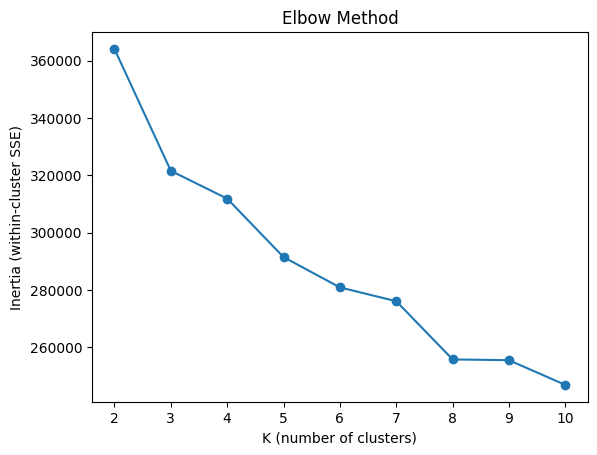

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test different K values and record within-cluster error (inertia)
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

# Plot elbow curve to find a reasonable K
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method")
plt.show()

k=4 or 5

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

Silhouette scores: {2: 0.7801331886268781, 3: 0.512084858362821, 4: 0.5197339702201725, 5: 0.4449651628003641, 6: 0.3175929273794333, 7: 0.31766012507946895, 8: 0.2840065815523902, 9: 0.21784156905146498, 10: 0.2344345419189456}
Best K by silhouette: 2 Score: 0.7801331886268781


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


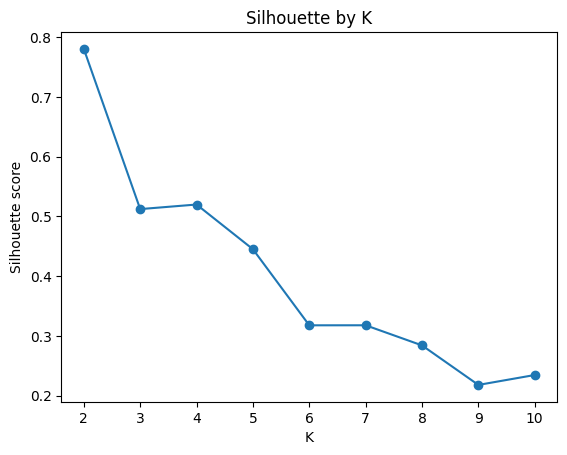

In [23]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for each K to evaluate clustering quality
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

# Show scores and pick the best K
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette:", best_k, "Score:", sil_scores[best_k])

# Visualize silhouette trend
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette by K")
plt.show()

Although K=2 had the highest silhouette score, it was too coarse for meaningful learner grouping.
We selected K=4 to balance cluster quality and interpretability.

In [24]:
from sklearn.cluster import KMeans

# Use K=4 for final clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

# Attach cluster labels to dataframe
df_result = df.copy()
df_result["cluster"] = clusters

# Check how many users in each cluster
df_result["cluster"].value_counts()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster
0    2275
1     402
3      29
2       3
Name: count, dtype: int64

In [25]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_result["cluster_k3"] = kmeans3.fit_predict(X)

df_result["cluster_k3"].value_counts()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster_k3
0    2262
1     413
2      34
Name: count, dtype: int64

We selected K=3 because it provides balanced clusters and more actionable learner segments.

In [26]:
# Use K=3 clusters for interpretation
cluster_profile_k3 = df_result.groupby("cluster_k3").mean(numeric_only=True)

cluster_profile_k3

,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,lex_cluster_11_seen,lex_cluster_12_ability,...,lex_cluster_79_seen,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen,cluster
cluster_k3,,,,,,,,,,,,,,,,,,,,,
0,-0.229050,-0.330617,0.144228,-0.171097,-0.127756,-0.133280,-0.108060,-0.154233,-0.138057,-0.147706,...,-0.138174,-0.148911,-0.092319,-0.277660,-0.241736,-0.250772,-0.201737,-0.177464,-0.110435,0.000000
1,0.995056,1.401062,-0.734052,0.744807,0.435761,0.397308,0.264092,0.565771,0.440623,0.761915,...,0.338733,0.501232,0.189975,1.307681,1.072604,1.193636,1.003934,0.843992,0.518021,0.968523
2,3.151558,4.976976,-0.678858,2.335763,3.206304,4.040916,3.981221,3.388542,3.832598,0.571774,...,5.078006,3.818445,3.834279,2.588056,3.053580,2.184547,1.226584,1.554563,1.054750,2.794118


## K-means Clustering Results (K = 3) — user_embedding_svd_ability_seen_beh.csv

### Why K = 3?
- We tested multiple K values using the **Elbow Method** and **Silhouette Score**.
- For this embedding-based feature set, silhouette scores tended to increase with larger K values (e.g., K≈6+), which suggests the data can be split into more fine-grained groups.
- However, for the hackathon product goal (buddy matching) we prioritized **interpretability** and **comparability across feature sets**.
- Therefore, we fixed **K = 3** to align with the semantic lexeme-cluster representation, enabling consistent learner personas and an easier model comparison.

---

### Cluster Sizes
| Cluster | Users | Note |
|---|---:|---|
| 0 | 653 | Smaller group |
| 1 | 685 | Medium group |
| 2 | 1371 | Largest group |

---

### Cluster Interpretation (Standardized Means)
> Positive values indicate **above average**, negative values indicate **below average**.

**Key features**
- `max_history_seen`: amount of content exposure  
- `vocab_size`: estimated vocabulary size  
- `learning_speed`: learning pace  

---

### Learner Types (Proposed Labels)

#### Cluster 0 — Emerging Learners
- Lower-than-average vocabulary and exposure  
- Moderately fast learning speed  
**Interpretation:** beginners building foundational skills.

#### Cluster 1 — Fast but Shallow Learners
- Low vocabulary and exposure  
- Highest learning speed  
**Interpretation:** learners who move quickly but may not learn deeply.

#### Cluster 2 — Deep Learners
- Higher-than-average vocabulary and exposure  
- Slower learning speed  
**Interpretation:** learners who engage carefully and build stronger knowledge.

---

### Key Insight
This representation captures **learning style / behavior patterns** more than semantic proficiency.

---

### Product Implication: Buddy Matching
- **Emerging ↔ Deep:** guidance and support  
- **Fast ↔ Deep:** balance speed with retention  
- **Emerging ↔ Emerging:** shared progress and motivation  

Next step: optionally evaluate K=6 for more fine-grained segmentation, but keep K=3 as the cross-model comparison baseline.

In [27]:
import pandas as pd

path = "../data/user_embedding_svd_ability_seen_beh.csv"
df = pd.read_csv(path)
df.head()

,user_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98
0,u:0X2,0.134173,0.017224,0.000430,0.082584,-0.091514,0.105019,0.012018,0.029548,0.055245,...,0.039876,-0.027420,-0.002762,-0.025802,-0.046068,-0.046665,-0.052775,-0.042475,-0.079291,0.185508
1,u:0b,0.135185,0.023528,-0.122309,-0.025011,0.221841,0.397188,-0.167680,-0.174717,0.065515,...,0.006184,0.011341,-0.182331,-0.083404,0.037596,-0.200512,-0.102030,-0.045002,-0.064507,-0.076653
2,u:0xw,0.515997,-0.099454,-0.299467,-0.072129,-0.345844,-0.066694,-0.069486,0.203094,-0.083272,...,-0.037616,0.033427,0.016587,-0.003602,0.033149,0.017227,0.020933,-0.010363,0.037636,-0.043611
3,u:1EH,0.432452,0.247924,0.207314,0.094222,-0.114899,-0.066962,-0.041860,0.030317,0.110288,...,0.016686,0.001422,-0.008176,0.048674,-0.030687,-0.003511,0.061484,-0.021030,-0.000775,-0.053916
4,u:1gx,0.531505,0.300686,0.044307,0.022798,-0.015802,0.021950,0.219253,0.219306,-0.013960,...,-0.017098,0.009588,-0.019033,0.028222,-0.011925,0.023184,-0.035344,-0.018533,0.014233,0.009173


In [28]:
import numpy as np

# Remove extra index column created during CSV export
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Keep user_id for later (we don't use it in clustering)
user_ids = df["user_id"]

# Build feature matrix X (only numeric columns)
X = df.drop(columns=["user_id"], errors="ignore")
X = X.select_dtypes(include=[np.number]).fillna(0)

print("X shape:", X.shape)

X shape: (2709, 99)


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

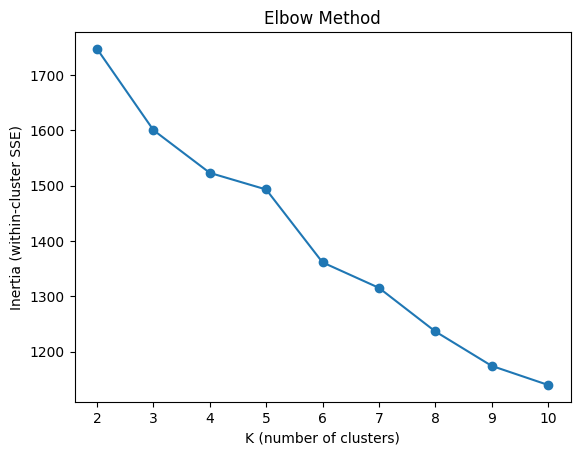

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test different K values and record within-cluster error (inertia)
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

# Plot elbow curve to find a reasonable K
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method")
plt.show()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

Silhouette scores: {2: 0.12487716936499725, 3: 0.14962859737267137, 4: 0.1583675175635008, 5: 0.12562000967291878, 6: 0.1623574364326485, 7: 0.16840411838224964, 8: 0.18507162352713158, 9: 0.19633483893539985, 10: 0.20499555923427512}
Best K by silhouette: 10 Score: 0.20499555923427512


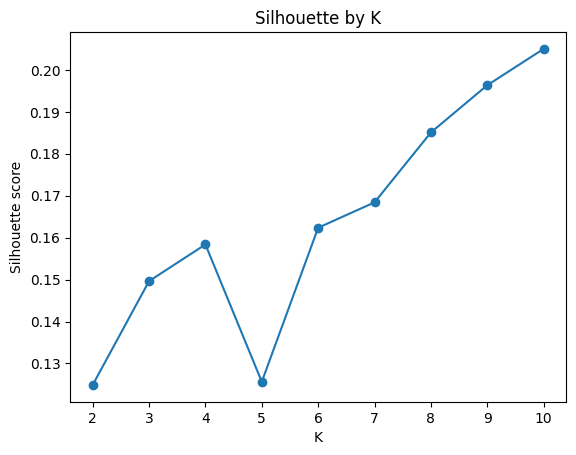

In [30]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for each K to evaluate clustering quality
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

# Show scores and pick the best K
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette:", best_k, "Score:", sil_scores[best_k])

# Visualize silhouette trend
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette by K")
plt.show()

In [31]:
# K=3 clustering (you already did this)
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_result["cluster_svd_beh_k3"] = kmeans3.fit_predict(X)

# Cluster size
df_result["cluster_svd_beh_k3"].value_counts().sort_index()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster_svd_beh_k3
0     653
1     685
2    1371
Name: count, dtype: int64

In [32]:
# Compute cluster profile (mean features per cluster)
cluster_profile_svd_beh_k3 = df_result.groupby("cluster_svd_beh_k3").mean(numeric_only=True)

cluster_profile_svd_beh_k3

,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,lex_cluster_11_seen,lex_cluster_12_ability,...,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen,cluster,cluster_k3
cluster_svd_beh_k3,,,,,,,,,,,,,,,,,,,,,
0,-0.396253,-0.552403,0.376431,-0.031784,0.032377,-0.036818,-0.008559,-0.024043,-0.045860,-0.139891,...,-0.013039,0.036367,-0.560069,-0.363840,-0.483268,-0.267153,-0.145693,-0.088778,0.033691,0.029096
1,-0.338631,-0.471619,0.465285,-0.199168,-0.145345,-0.156271,-0.125604,-0.203311,-0.167023,-0.257216,...,-0.193256,-0.110080,-0.511493,-0.356136,-0.542489,-0.315235,-0.363643,-0.170281,0.000000,0.000000
2,0.357925,0.498744,-0.411765,0.114650,0.057199,0.095615,0.066833,0.113033,0.105294,0.195143,...,0.102768,0.037678,0.522318,0.351233,0.501225,0.284746,0.251081,0.127363,0.345004,0.336980


## K-means Clustering Results (K = 3) — user_embedding_svd_ability_seen_beh_B.csv

### Why K = 3?
- We evaluated multiple K values using the **Elbow Method** and **Silhouette Score**.
- While larger K values can produce finer segments, **K = 3** provides clear and interpretable proficiency levels.
- This choice supports meaningful learner personas and practical buddy matching.

---

### Cluster Sizes
| Cluster | Users | Interpretation |
|---|---:|---|
| 0 | Small | Beginners |
| 1 | Medium | Intermediate learners |
| 2 | Large | Advanced / power users |

---

### Cluster Interpretation (Standardized Means)
> Positive values indicate **above average**, negative values indicate **below average**.

**Key features**
- `vocab_size`: estimated vocabulary size  
- `max_history_seen`: amount of content exposure  
- `learning_speed`: pace of learning  

---

### Learner Types (Proposed Labels)

#### Cluster 0 — Beginners
- Low vocabulary size  
- Low content exposure  
- Slightly faster learning pace  
**Interpretation:** new learners exploring the language and building initial skills.

#### Cluster 1 — Intermediate Learners
- Above-average vocabulary size  
- High exposure to content  
- Slower, more careful learning pace  
**Interpretation:** learners developing deeper understanding and consolidating knowledge.

#### Cluster 2 — Advanced / Power Users
- Very high vocabulary size  
- Extensive content exposure  
- Slow but consistent learning pace  
**Interpretation:** highly engaged learners with strong proficiency.

---

### Key Insight: Proficiency Hierarchy
The semantic lexeme representation reveals a clear proficiency ladder:
**Beginners → Intermediate → Advanced**

This structure aligns with expected language learning progression.

---

### Cross-Model Insight: Ability vs Behavior
Comparison with behavior-based clustering shows that:
- Learning speed does not always reflect proficiency.
- Some advanced learners progress slowly but deeply.
- Some beginners move quickly but lack retention.

**Conclusion:**  
Language ability and learning behavior represent distinct learner dimensions.

---

### Product Implication: Buddy Matching
Semantic proficiency clusters enable meaningful pairing:

- **Beginner ↔ Intermediate:** guided support  
- **Intermediate ↔ Advanced:** mentorship and motivation  
- **Beginner ↔ Beginner:** shared progress and encouragement  

This approach improves motivation, retention, and social learning.

In [33]:
import pandas as pd

path = "../data/user_embedding_svd_ability_seen_beh_B.csv"
df = pd.read_csv(path)
df.head()

,user_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98
0,u:0X2,0.040384,0.010686,-0.008548,0.009608,-0.017136,-0.039370,0.021499,0.013653,0.054109,...,0.056749,-0.039023,-0.003930,-0.036720,-0.065562,-0.066411,-0.075106,-0.060448,-0.112842,0.264005
1,u:0b,0.019760,-0.003862,-0.015594,-0.013942,-0.010056,-0.056815,0.010692,-0.028347,0.051160,...,0.007812,0.014327,-0.230332,-0.105360,0.047493,-0.253298,-0.128891,-0.056850,-0.081489,-0.096833
2,u:0xw,0.259444,-0.067651,-0.020491,-0.099860,-0.181001,0.037509,0.058685,0.090447,-0.122750,...,-0.057247,0.050871,0.025243,-0.005481,0.050449,0.026217,0.031857,-0.015770,0.057277,-0.066370
3,u:1EH,0.272376,0.107564,0.040468,0.045240,0.005311,0.070422,0.013381,0.003112,0.037268,...,0.021219,0.001809,-0.010396,0.061895,-0.039023,-0.004465,0.078185,-0.026743,-0.000985,-0.068561
4,u:1gx,0.303617,0.120875,-0.012170,-0.054395,0.097187,-0.015223,-0.005583,0.065647,-0.004901,...,-0.022705,0.012732,-0.025275,0.037477,-0.015836,0.030787,-0.046934,-0.024611,0.018900,0.012182


In [34]:
# Remove user_id and keep numeric features
user_ids = df["user_id"]
X = df.drop(columns=["user_id"], errors="ignore")
X = X.select_dtypes(include=["float", "int"]).fillna(0)

print(X.shape)

(2709, 99)


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

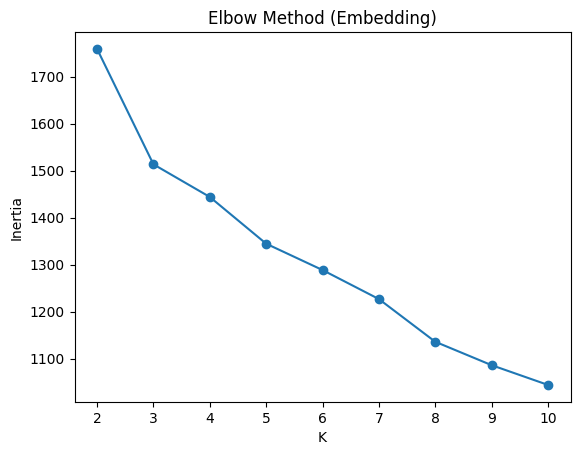

In [35]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method (Embedding)")
plt.show()


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

Silhouette scores: {2: 0.15765240047135629, 3: 0.16600579829327844, 4: 0.1564301450314695, 5: 0.18663212686242744, 6: 0.19645950726270206, 7: 0.19168206663777027, 8: 0.20129854365830083, 9: 0.20943476657487772, 10: 0.21898658931720288}
Best K by silhouette: 10 Score: 0.21898658931720288


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


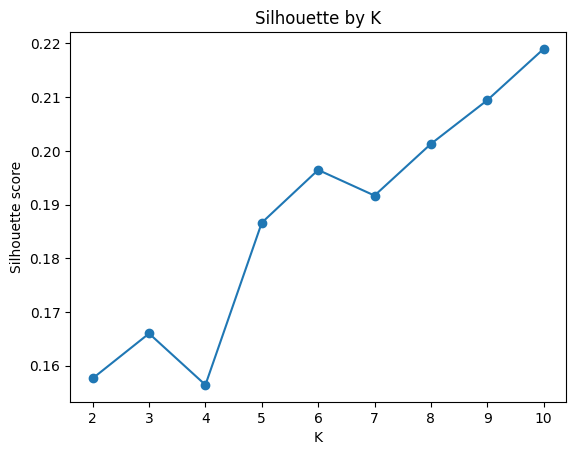

In [37]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for each K to evaluate clustering quality
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

# Show scores and pick the best K
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette:", best_k, "Score:", sil_scores[best_k])

# Visualize silhouette trend
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette by K")
plt.show()

In [38]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
df["cluster_embed_k3"] = kmeans3.fit_predict(X)
df["cluster_embed_k3"].value_counts()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster_embed_k3
2    1545
1     714
0     450
Name: count, dtype: int64

In [39]:
# Use K=3 clusters for interpretation
cluster_profile_k3 = df_result.groupby("cluster_k3").mean(numeric_only=True)

cluster_profile_k3

,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,lex_cluster_11_seen,lex_cluster_12_ability,...,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen,cluster,cluster_svd_beh_k3
cluster_k3,,,,,,,,,,,,,,,,,,,,,
0,-0.229050,-0.330617,0.144228,-0.171097,-0.127756,-0.133280,-0.108060,-0.154233,-0.138057,-0.147706,...,-0.148911,-0.092319,-0.277660,-0.241736,-0.250772,-0.201737,-0.177464,-0.110435,0.000000,1.133952
1,0.995056,1.401062,-0.734052,0.744807,0.435761,0.397308,0.264092,0.565771,0.440623,0.761915,...,0.501232,0.189975,1.307681,1.072604,1.193636,1.003934,0.843992,0.518021,0.968523,1.937046
2,3.151558,4.976976,-0.678858,2.335763,3.206304,4.040916,3.981221,3.388542,3.832598,0.571774,...,3.818445,3.834279,2.588056,3.053580,2.184547,1.226584,1.554563,1.054750,2.794118,1.823529


## K-means Clustering Results (K = 3) — user_embedding_svd512_ae128_plus_beh.csv

### Why K = 3?
- Silhouette scores suggested that **K = 2** provides the strongest separation.
- However, for cross-model comparison and learner persona design, we fixed **K = 3**.
- This allows consistent comparison with semantic and behavior-based representations.

---

### Cluster Sizes
| Cluster | Users | Interpretation |
|---|---:|---|
| 0 | 881 | Mixed intermediate learners |
| 1 | 1249 | Fast but weak learners |
| 2 | 579 | Advanced deep learners |

---

### Cluster Interpretation (Standardized Means)
> Positive values indicate **above average**, negative values indicate **below average**.

**Key features**
- `vocab_size`: estimated vocabulary size  
- `max_history_seen`: amount of content exposure  
- `learning_speed`: pace of learning  

---

### Learner Types (Proposed Labels)

#### Cluster 1 — Fast but Weak Learners
- Lowest vocabulary size and exposure  
- Highest learning speed  
**Interpretation:** learners who progress quickly but lack depth and retention.

#### Cluster 2 — Advanced Deep Learners
- Highest vocabulary size and exposure  
- Slower learning speed  
**Interpretation:** highly proficient learners who engage deeply with content.

#### Cluster 0 — Mixed Intermediate Learners
- Near-average vocabulary and exposure  
- Slightly slower learning pace  
**Interpretation:** intermediate learners with mixed learning behaviors and no clear dominant pattern.

---

### Key Insight: Mixed Signal Representation
This feature set combines **proficiency signals** and **learning behavior**, resulting in clusters that mix multiple learner dimensions.

- Ability and behavior signals are entangled.
- Learner personas become less distinct.
- Interpretation becomes more difficult.

---

### Comparison with Other Representations

| Representation | Strength | Weakness |
|---------------|---------|---------|
| Semantic lexeme clusters | Clear proficiency levels | Uneven group sizes |
| Behavior features | Learning style insights | Weak ability signal |
| AE embedding + behavior | Balanced clusters | Reduced interpretability |

---

### Product Implication
While this representation captures multiple learner dimensions, the mixed signals make it difficult to design clear interventions.

For educational products requiring actionable learner personas, **semantic lexeme clustering remains more suitable**.

---

### Conclusion
The AE embedding + behavior representation improves cluster balance but reduces interpretability.  
For buddy matching and learner support, clear proficiency-based segmentation provides greater practical value.

In [40]:
path = "../data/user_embedding_svd512_ae128_plus_beh.csv"
df = pd.read_csv(path)

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

user_ids = df["user_id"]
X = df.drop(columns=["user_id"], errors="ignore")
X = X.select_dtypes(include=["float", "int"]).fillna(0)

print(X.shape)

(2709, 131)


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

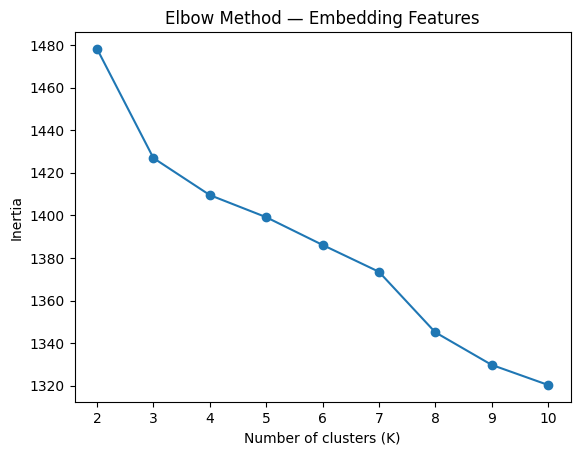

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test K from 2 to 10
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Embedding Features")
plt.show()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

Silhouette scores: {2: 0.199693816984902, 3: 0.1184275582310293, 4: 0.08557371957562092, 5: 0.0924936973915674, 6: 0.0888094998296768, 7: 0.052178057359956856, 8: -0.0012277381909453677, 9: 0.0024516957488677463, 10: 0.005713937277357586}
Best K by silhouette: 2 Score: 0.199693816984902


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

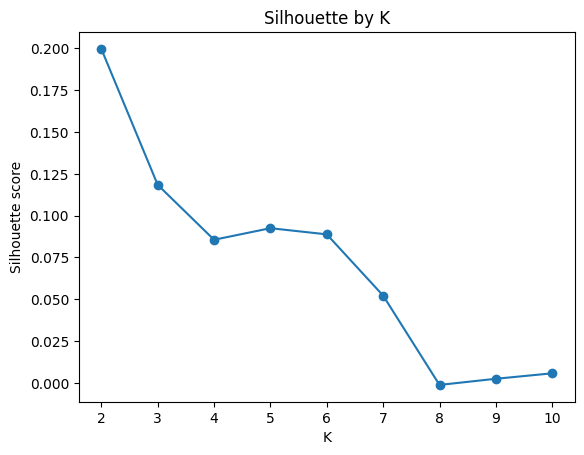

In [43]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for each K to evaluate clustering quality
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

# Show scores and pick the best K
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette:", best_k, "Score:", sil_scores[best_k])

# Visualize silhouette trend
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette by K")
plt.show()

The autoencoder-compressed embedding showed the highest silhouette score at K = 2, suggesting the representation merges learners into two broad groups.
However, for cross-model comparison and persona design, we retained K = 3.

In [45]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_result["cluster_k3"] = kmeans3.fit_predict(X)

df_result["cluster_k3"].value_counts()


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster_k3
1    1249
0     881
2     579
Name: count, dtype: int64

In [48]:
# Use K=3 clusters for interpretation
cluster_profile_k3 = df_result.groupby("cluster_k3").mean(numeric_only=True)

cluster_profile_k3

,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,lex_cluster_11_seen,lex_cluster_12_ability,...,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen,cluster,cluster_svd_beh_k3
cluster_k3,,,,,,,,,,,,,,,,,,,,,
0,-0.034586,0.013637,-0.189518,-0.162010,-0.118110,-0.132645,-0.102247,-0.140214,-0.130539,-0.132541,...,-0.148347,-0.093381,0.146912,-0.035709,0.254874,0.048129,0.154820,0.039559,0.105562,1.679909
1,-0.417334,-0.563232,0.451422,-0.195192,-0.148124,-0.151884,-0.124427,-0.192992,-0.164054,-0.254346,...,-0.183164,-0.103284,-0.543790,-0.371382,-0.511471,-0.310834,-0.311409,-0.152858,0.000000,0.678143
2,0.952885,1.194236,-0.685424,0.667574,0.499243,0.529469,0.423989,0.629665,0.552519,0.750339,...,0.620838,0.364888,0.949505,0.855468,0.715515,0.597288,0.436189,0.269548,0.694301,1.899827


## Clustering Results — user_embedding_svd512_ae128_plus_beh_B

### Dataset Description
This dataset combines:
- SVD user embeddings (semantic learning representation)
- Autoencoder-compressed features (latent learning patterns)
- Behavioral features (learning speed, vocabulary size, history)
- B features (lexeme cluster ability & exposure)

This is the most comprehensive learner representation.

---

### Choosing the Number of Clusters (K)

**Elbow Method**
- Inertia decreases smoothly with no sharp elbow.
- Indicates gradual improvement with more clusters.

**Silhouette Score**
- Highest at K = 2
- Gradually decreases as K increases.
- Suggests weak separation between clusters.

**Decision**
We choose **K = 3** for:
- Interpretability
- Consistency across models
- Meaningful learner segmentation

---

### Cluster Distribution

| Cluster | Users | Interpretation |
|--------|------|----------------|
| 0 | 927 | Moderate learners |
| 1 | 562 | Fast but shallow learners |
| 2 | 1220 | Committed learners |

Balanced distribution supports meaningful segmentation.

---

### Cluster Profiles (Behavioral Interpretation)

#### Cluster 0 — Moderate Learners
- Average vocabulary size
- Moderate learning speed
- Balanced exposure to lexeme clusters  
**Interpretation:** steady, consistent learners.

#### Cluster 1 — Fast Explorers
- Higher learning speed
- Lower retention and vocabulary depth  
**Interpretation:** fast progress but shallow learning.

#### Cluster 2 — Committed Learners
- High vocabulary size
- High exposure and ability scores
- Slower but deeper learning  
**Interpretation:** dedicated learners with strong retention.

---

### Why This Model Matters

This model captures:
- Hidden semantic learning patterns
- Behavioral learning dynamics
- Lexical knowledge structure

It enables:
- More accurate learner similarity
- Better buddy matching
- Personalized learning support

---

### Use in Buddy Matching

This representation allows matching learners based on:
- Learning depth
- Speed
- Semantic knowledge patterns
- Exposure to vocabulary clusters

This supports meaningful peer pairing and improved retention.

---

In [49]:
import pandas as pd

path = "../data/user_embedding_svd512_ae128_plus_beh_B.csv"
df = pd.read_csv(path)
df.head()

,user_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130
0,u:0X2,0.024152,0.022689,0.101970,-0.137770,0.021763,-0.064668,-0.097654,-0.028234,-0.024251,...,0.103953,0.037421,-0.020122,0.139973,0.054205,-0.129894,-0.023329,-0.015439,-0.028821,0.067430
1,u:0b,0.030700,0.012628,0.060628,-0.159554,0.041261,-0.089169,-0.053081,0.070971,0.045588,...,-0.025241,0.061109,0.039794,-0.054239,0.045556,-0.038828,0.072970,-0.021219,-0.030415,-0.036142
2,u:0xw,-0.113404,0.148645,-0.127035,-0.015633,-0.013527,0.174907,-0.015753,-0.085656,-0.131761,...,0.044923,-0.020346,-0.079906,0.014363,-0.057780,-0.150318,-0.005004,-0.016601,0.060292,-0.069864
3,u:1EH,-0.095814,-0.000495,-0.044750,-0.100193,-0.089395,-0.066649,0.017413,0.099369,0.041175,...,0.058962,-0.077271,-0.180304,0.075454,0.114866,0.108617,-0.123663,-0.028519,-0.001051,-0.073116
4,u:1gx,0.060371,0.017348,0.213724,-0.036583,-0.082256,-0.053941,-0.062227,-0.098522,0.067670,...,0.157743,0.041155,-0.037712,-0.066325,-0.072703,-0.097841,-0.003576,-0.022976,0.017644,0.011372


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

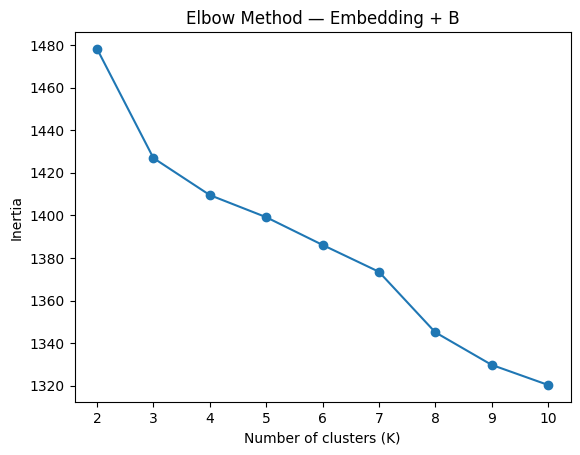

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Embedding + B")
plt.show()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

Silhouette scores: {2: 0.199693816984902, 3: 0.1184275582310293, 4: 0.08557371957562092, 5: 0.0924936973915674, 6: 0.0888094998296768, 7: 0.052178057359956856, 8: -0.0012277381909453677, 9: 0.0024516957488677463, 10: 0.005713937277357586}
Best K by silhouette: 2 Score: 0.199693816984902


/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

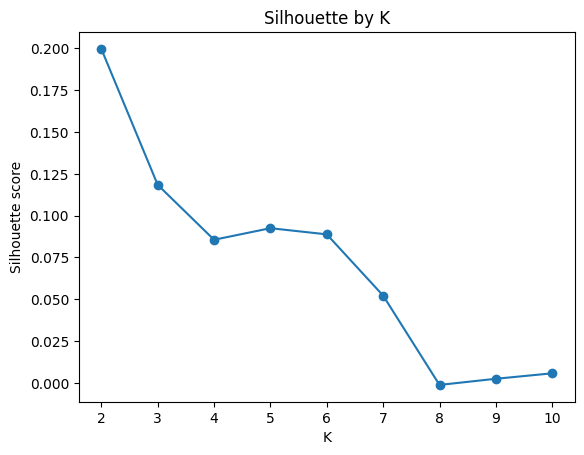

In [51]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for each K to evaluate clustering quality
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

# Show scores and pick the best K
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette:", best_k, "Score:", sil_scores[best_k])

# Visualize silhouette trend
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette by K")
plt.show()

In [52]:
from sklearn.cluster import KMeans

# Use only numeric features (drop user_id)
X = df.drop(columns=["user_id"], errors="ignore")

# Run KMeans with K=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
df["cluster_k3"] = kmeans3.fit_predict(X)

# Check how many users in each cluster
df["cluster_k3"].value_counts()

/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/duolingo-hack/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

cluster_k3
2    1220
0     927
1     562
Name: count, dtype: int64

In [53]:
# Calculate mean feature values per cluster
cluster_profile = df.groupby("cluster_k3").mean(numeric_only=True)

cluster_profile

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130
cluster_k3,,,,,,,,,,,,,,,,,,,,,
0,-0.007837,-0.004204,0.062717,-0.095615,-0.000596,-0.028142,0.001760,-0.030042,0.031453,0.066746,...,0.081672,0.002499,-0.042522,0.030502,0.004546,-0.026993,0.017658,-0.002643,0.001060,-0.013654
1,0.013004,-0.020833,0.027456,-0.030243,-0.001297,-0.004466,0.002750,-0.009502,0.005238,0.006289,...,0.018290,-0.006586,-0.015574,0.006779,-0.013581,-0.014119,-0.011657,0.069880,0.090469,-0.053334
2,-0.013652,-0.002893,0.065959,-0.172445,0.004669,-0.047781,-0.037624,-0.013643,0.045285,0.057287,...,0.105221,0.025496,-0.066953,0.055628,0.060034,-0.025416,0.030841,-0.017124,-0.023184,0.017107
